# Ensemble + Bias Investigation

Loads saved validation predictions from the LambdaRank and pointwise notebooks, then evaluates the blend and bias metrics.

In [1]:
import sys
from pathlib import Path

cwd = Path(".").resolve()
REPO_ROOT = cwd
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / ".git").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"Could not find repo root from {cwd}")
sys.path.insert(0, str(REPO_ROOT))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import DATA_DIR, DTYPES_TRAIN, compute_ndcg_fast

### Load Model Artifacts

In [2]:
out_dir = REPO_ROOT / "outputs"
lr_pred_path = out_dir / "lambdarank_val_preds.parquet"
pw_pred_path = out_dir / "pointwise_val_preds.parquet"

missing = [str(p) for p in [lr_pred_path, pw_pred_path] if not p.exists()]
if missing:
    raise FileNotFoundError("Run the LambdaRank and pointwise notebooks first. Missing: " + ", ".join(missing))

lr_preds = pd.read_parquet(lr_pred_path).rename(columns={"pred_score": "lr_score"})
pw_preds = pd.read_parquet(pw_pred_path).rename(columns={"pred_score": "pw_score"})

required_lr = {"srch_id", "prop_id", "booking_bool", "click_bool", "lr_score"}
required_pw = {"srch_id", "prop_id", "pw_score"}
if not required_lr.issubset(lr_preds.columns):
    raise ValueError(f"{lr_pred_path.name} missing columns: {sorted(required_lr - set(lr_preds.columns))}")
if not required_pw.issubset(pw_preds.columns):
    raise ValueError(f"{pw_pred_path.name} missing columns: {sorted(required_pw - set(pw_preds.columns))}")

val_df_eval = lr_preds[["srch_id", "prop_id", "booking_bool", "click_bool", "lr_score"]].merge(
    pw_preds[["srch_id", "prop_id", "pw_score"]],
    on=["srch_id", "prop_id"],
    how="inner",
)
if len(val_df_eval) != len(lr_preds):
    raise ValueError("Prediction artifacts do not align on srch_id/prop_id")

print(f"Loaded {len(val_df_eval):,} aligned validation predictions")


def load_json(path):
    return json.loads(path.read_text()) if path.exists() else {}

lr_meta = load_json(out_dir / "lambdarank_run1.json")
pw_meta = load_json(out_dir / "pointwise_run1.json")
print(f"LambdaRank artifact NDCG@5: {lr_meta.get('model_ndcg5', 'unknown')}")
print(f"Pointwise artifact NDCG@5:  {pw_meta.get('model_ndcg5', 'unknown')}")

Loaded 991,665 aligned validation predictions
LambdaRank artifact NDCG@5: 0.3911
Pointwise artifact NDCG@5:  0.3982


### Ensemble

  alpha=0.0  NDCG@5=0.4004


  alpha=0.1  NDCG@5=0.4012


  alpha=0.2  NDCG@5=0.4016


  alpha=0.3  NDCG@5=0.4016


  alpha=0.4  NDCG@5=0.4018


...

  alpha=0.6  NDCG@5=0.4023


  alpha=0.7  NDCG@5=0.4019


  alpha=0.8  NDCG@5=0.4004


  alpha=0.9  NDCG@5=0.3985


  alpha=1.0  NDCG@5=0.3944

Best ensemble: alpha=0.5, NDCG@5=0.4026
LambdaRank alone:  0.3944
Pointwise alone:   0.4004
Ensemble gain:     +0.0022


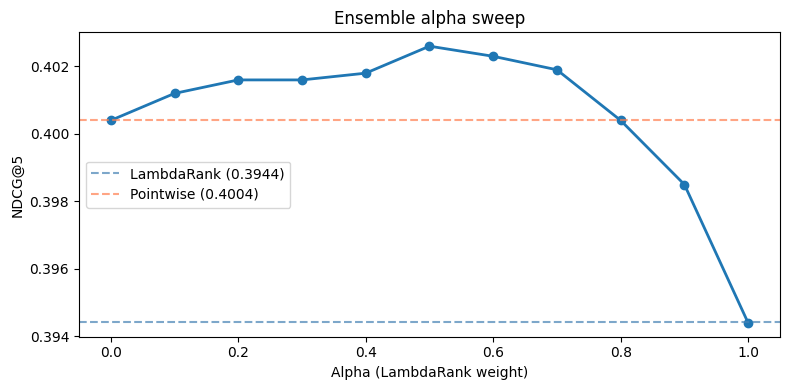

In [3]:
def normalize_per_search(df, col):
    g = df.groupby("srch_id")[col]
    mn = g.transform("min")
    mx = g.transform("max")
    rng = (mx - mn).replace(0, 1)
    return ((df[col] - mn) / rng).astype("float32")

val_df_eval["lr_norm"] = normalize_per_search(val_df_eval, "lr_score")
val_df_eval["pw_norm"] = normalize_per_search(val_df_eval, "pw_score")

lr_ndcg = compute_ndcg_fast(val_df_eval, "lr_score")
pw_ndcg = compute_ndcg_fast(val_df_eval, "pw_score")

ensemble_results = []
for alpha in np.arange(0.0, 1.05, 0.1):
    val_df_eval["ensemble_score"] = alpha * val_df_eval["lr_norm"] + (1 - alpha) * val_df_eval["pw_norm"]
    ndcg = compute_ndcg_fast(val_df_eval, "ensemble_score")
    ensemble_results.append({"alpha": round(float(alpha), 2), "ndcg5": round(float(ndcg), 4)})
    print(f"  alpha={alpha:.1f}  NDCG@5={ndcg:.4f}")

ensemble_df = pd.DataFrame(ensemble_results)
best_row = ensemble_df.loc[ensemble_df["ndcg5"].idxmax()]
best_alpha = float(best_row["alpha"])
best_ensemble_ndcg = float(best_row["ndcg5"])
val_df_eval["ensemble_score"] = best_alpha * val_df_eval["lr_norm"] + (1 - best_alpha) * val_df_eval["pw_norm"]

print(f"\nBest ensemble: alpha={best_alpha:.1f}, NDCG@5={best_ensemble_ndcg:.4f}")
print(f"LambdaRank alone:  {lr_ndcg:.4f}")
print(f"Pointwise alone:   {pw_ndcg:.4f}")
print(f"Ensemble gain:     +{best_ensemble_ndcg - max(lr_ndcg, pw_ndcg):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ensemble_df["alpha"], ensemble_df["ndcg5"], marker="o", linewidth=2)
ax.axhline(lr_ndcg, linestyle="--", color="steelblue", alpha=0.7, label=f"LambdaRank ({lr_ndcg:.4f})")
ax.axhline(pw_ndcg, linestyle="--", color="coral", alpha=0.7, label=f"Pointwise ({pw_ndcg:.4f})")
ax.set_xlabel("Alpha (LambdaRank weight)")
ax.set_ylabel("NDCG@5")
ax.set_title("Ensemble alpha sweep")
ax.legend()
plt.tight_layout()
plt.show()

### Bias Investigation

In [4]:
group_cols = [
    "srch_id",
    "prop_id",
    "srch_children_count",
    "visitor_location_country_id",
    "prop_country_id",
]
group_dtypes = {col: DTYPES_TRAIN[col] for col in group_cols}
group_df = pd.read_csv(
    DATA_DIR / "training_set_VU_DM.csv",
    usecols=group_cols,
    dtype=group_dtypes,
    na_values=["NULL"],
)

val_df_eval = val_df_eval.merge(group_df, on=["srch_id", "prop_id"], how="left")
if val_df_eval[group_cols[2:]].isna().any().any():
    raise ValueError("Could not attach bias group columns to all validation predictions")

val_df_eval["is_family"] = (val_df_eval["srch_children_count"] > 0).astype("int8")
val_df_eval["is_domestic"] = (
    val_df_eval["visitor_location_country_id"] == val_df_eval["prop_country_id"]
).astype("int8")

family_counts = val_df_eval.groupby("srch_id")["is_family"].first().value_counts()
domestic_counts = val_df_eval["is_domestic"].value_counts()
print("Family group sizes by search:")
print(family_counts.to_string())
print("\nDomestic/international row counts:")
print(domestic_counts.to_string())

Family group sizes by search:
is_family
0    30168
1     9791

Domestic/international row counts:
is_domestic
1    629461
0    362204


In [5]:
def per_group_ndcg(eval_df, group_col, score_col):
    results = {}
    for group_val, label in [(0, f"not_{group_col}"), (1, group_col)]:
        subset = eval_df[eval_df[group_col] == group_val]
        if len(subset) == 0:
            continue
        results[label] = {
            "ndcg5": round(float(compute_ndcg_fast(subset, score_col)), 4),
            "n_searches": int(subset["srch_id"].nunique()),
            "n_rows": int(len(subset)),
        }
    return results


def ranking_fairness_metrics(eval_df, group_col, score_col):
    df = eval_df.copy()
    df["_rank"] = df.groupby("srch_id")[score_col].rank(method="first", ascending=False).astype(int)
    booked = df[df["booking_bool"] == 1].copy()
    booked["booked_in_top5"] = (booked["_rank"] <= 5).astype(int)
    results = {}
    for group_val in sorted(booked[group_col].dropna().unique()):
        subset = booked[booked[group_col] == group_val]
        results[int(group_val)] = {
            "recall_at_5": round(float(subset["booked_in_top5"].mean()), 4),
            "n_bookings": int(len(subset)),
        }
    return results

score_col = "ensemble_score"
family_ndcg = per_group_ndcg(val_df_eval, "is_family", score_col)
domestic_ndcg = per_group_ndcg(val_df_eval, "is_domestic", score_col)
family_fairness = ranking_fairness_metrics(val_df_eval, "is_family", score_col)
domestic_fairness = ranking_fairness_metrics(val_df_eval, "is_domestic", score_col)

print("Per-group NDCG@5 (ensemble):")
print("Family:", family_ndcg)
print("Domestic/international:", domestic_ndcg)
print("\nRecall@5 fairness metrics:")
print("Family:", family_fairness)
print("Domestic/international:", domestic_fairness)

Per-group NDCG@5 (ensemble):
Family: {'not_is_family': {'ndcg5': 0.3968, 'n_searches': 30168, 'n_rows': 765540}, 'is_family': {'ndcg5': 0.4203, 'n_searches': 9791, 'n_rows': 226125}}
Domestic/international: {'not_is_domestic': {'ndcg5': 0.3869, 'n_searches': 14810, 'n_rows': 362204}, 'is_domestic': {'ndcg5': 0.4108, 'n_searches': 25217, 'n_rows': 629461}}

Recall@5 fairness metrics:
Family: {0: {'recall_at_5': 0.614, 'n_bookings': 20762}, 1: {'recall_at_5': 0.6359, 'n_bookings': 6767}}
Domestic/international: {0: {'recall_at_5': 0.6064, 'n_bookings': 9558}, 1: {'recall_at_5': 0.6263, 'n_bookings': 17971}}


### Post-Processing Mitigation

In [6]:
# Family status is search-level, so adding a group score shift would not change within-search rankings.
# Use domestic/international as an item-level group for post-processing mitigation.
domestic_scores = {0: domestic_ndcg.get("not_is_domestic", {}).get("ndcg5"), 1: domestic_ndcg.get("is_domestic", {}).get("ndcg5")}
under_group = min((k for k, v in domestic_scores.items() if v is not None), key=lambda k: domestic_scores[k])

mitigation_rows = []
for boost in np.arange(0.0, 0.205, 0.01):
    score_name = "mitigated_score"
    val_df_eval[score_name] = val_df_eval["ensemble_score"] + boost * (val_df_eval["is_domestic"] == under_group)
    overall = compute_ndcg_fast(val_df_eval, score_name)
    groups = per_group_ndcg(val_df_eval, "is_domestic", score_name)
    g0 = groups.get("not_is_domestic", {}).get("ndcg5")
    g1 = groups.get("is_domestic", {}).get("ndcg5")
    gap = abs(g1 - g0) if g0 is not None and g1 is not None else np.nan
    mitigation_rows.append({"boost": round(float(boost), 2), "overall_ndcg5": overall, "gap": gap, "g0_ndcg5": g0, "g1_ndcg5": g1})

mitigation_df = pd.DataFrame(mitigation_rows)
eligible = mitigation_df[mitigation_df["overall_ndcg5"] >= best_ensemble_ndcg - 0.005]
best_mitigation = eligible.sort_values(["gap", "overall_ndcg5"], ascending=[True, False]).iloc[0]
best_boost = float(best_mitigation["boost"])
val_df_eval["mitigated_score"] = val_df_eval["ensemble_score"] + best_boost * (val_df_eval["is_domestic"] == under_group)

mitigated_overall_ndcg = compute_ndcg_fast(val_df_eval, "mitigated_score")
mitigated_domestic_ndcg = per_group_ndcg(val_df_eval, "is_domestic", "mitigated_score")
mitigated_domestic_fairness = ranking_fairness_metrics(val_df_eval, "is_domestic", "mitigated_score")

print(f"Underperforming item group: {'domestic' if under_group == 1 else 'international'}")
print(f"Best boost: {best_boost:.2f}")
print(f"Original overall NDCG@5:  {best_ensemble_ndcg:.4f}")
print(f"Mitigated overall NDCG@5: {mitigated_overall_ndcg:.4f}")
print("Original domestic/international NDCG:", domestic_ndcg)
print("Mitigated domestic/international NDCG:", mitigated_domestic_ndcg)
print("Mitigated recall@5:", mitigated_domestic_fairness)

Underperforming item group: international
Best boost: 0.02
Original overall NDCG@5:  0.4026
Mitigated overall NDCG@5: 0.4026
Original domestic/international NDCG: {'not_is_domestic': {'ndcg5': 0.3869, 'n_searches': 14810, 'n_rows': 362204}, 'is_domestic': {'ndcg5': 0.4108, 'n_searches': 25217, 'n_rows': 629461}}
Mitigated domestic/international NDCG: {'not_is_domestic': {'ndcg5': 0.3869, 'n_searches': 14810, 'n_rows': 362204}, 'is_domestic': {'ndcg5': 0.4108, 'n_searches': 25217, 'n_rows': 629461}}
Mitigated recall@5: {0: {'recall_at_5': 0.6064, 'n_bookings': 9558}, 1: {'recall_at_5': 0.6263, 'n_bookings': 17971}}


In [7]:
results_out = {
    "ensemble": {
        "best_alpha": best_alpha,
        "ndcg5": best_ensemble_ndcg,
        "lambdarank_ndcg5": round(float(lr_ndcg), 4),
        "pointwise_ndcg5": round(float(pw_ndcg), 4),
    },
    "bias_investigation": {
        "detection": {
            "family_vs_nonfamily": family_ndcg,
            "domestic_vs_international": domestic_ndcg,
            "family_recall_at_5": family_fairness,
            "domestic_recall_at_5": domestic_fairness,
        },
        "mitigation": {
            "technique": "post-processing score boost",
            "group": "domestic_vs_international",
            "boosted_group": "domestic" if under_group == 1 else "international",
            "boost": best_boost,
            "original_overall_ndcg5": best_ensemble_ndcg,
            "mitigated_overall_ndcg5": round(float(mitigated_overall_ndcg), 4),
            "mitigated_group_ndcg5": mitigated_domestic_ndcg,
            "mitigated_recall_at_5": mitigated_domestic_fairness,
        },
    },
    "artifacts": {
        "lambdarank": str(lr_pred_path.relative_to(REPO_ROOT)),
        "pointwise": str(pw_pred_path.relative_to(REPO_ROOT)),
    },
}

with open(out_dir / "ensemble_bias_results.json", "w") as f:
    json.dump(results_out, f, indent=2)

print("Results saved to outputs/ensemble_bias_results.json")

Results saved to outputs/ensemble_bias_results.json
